In [ ]:
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

#  seed to get same outputs when re run the code

In [ ]:
import os  # to access files from os
import json
from zipfile import ZipFile   # to extract kaggle zip dataset
from PIL import ImageChops     # img processing
from PIL import Image


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [ ]:
!pip install kaggle # for jupyter notebooks

In [ ]:
kaggle_credentials= json.load(open("kaggle.json"))

In [ ]:
os.environ['KAGGLE_USERNAME']=kaggle_credentials["username"]
os.environ['KAGGLE_KEY']=kaggle_credentials["key"]

In [ ]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [01:40<00:00, 24.1MB/s]
100% 2.04G/2.04G [01:40<00:00, 21.8MB/s]


In [ ]:
!ls #check required data is present

kaggle.json  plantvillage-dataset.zip  sample_data


In [ ]:
with ZipFile("plantvillage-dataset.zip", 'r') as zip_ref:
  zip_ref.extractall()

In [ ]:
print(os.listdir("plantvillage dataset"))

print(len(os.listdir("plantvillage dataset/segmented")))  #lenght of sub directories in segmented
print(os.listdir("plantvillage dataset/segmented")[:5])    #printing first 5 names of these sub directories

print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))
print(os.listdir("plantvillage dataset/grayscale")[:5])

#we will be working on color directory

['color', 'segmented', 'grayscale']
38
['Tomato___Early_blight', 'Potato___healthy', 'Apple___Cedar_apple_rust', 'Strawberry___healthy', 'Cherry_(including_sour)___healthy']
38
['Tomato___Early_blight', 'Potato___healthy', 'Apple___Cedar_apple_rust', 'Strawberry___healthy', 'Cherry_(including_sour)___healthy']
38
['Tomato___Early_blight', 'Potato___healthy', 'Apple___Cedar_apple_rust', 'Strawberry___healthy', 'Cherry_(including_sour)___healthy']


In [ ]:
# number of classes =38

In [ ]:
print(len(os.listdir("plantvillage dataset/color/Grape___healthy")))
print(os.listdir("plantvillage dataset/color/Grape___healthy")[:5])

423
['11c32403-6d55-4f16-8c16-fae9c04a9920___Mt.N.V_HL 9008.JPG', 'bc9f03e8-d545-4ba9-a68d-7032b3c36670___Mt.N.V_HL 6075.JPG', 'b2de09b2-4c5d-4be5-a06f-27419db0f696___Mt.N.V_HL 6097.JPG', '6dc550f9-1939-4184-8efd-4afd6508ae3c___Mt.N.V_HL 9026.JPG', '8253f8a0-545c-4020-babf-46abad8260cf___Mt.N.V_HL 6161.JPG']


In [ ]:
## DATA PREPROCESSING

base_dir='plantvillage dataset/color'  #dataset path

(256, 256, 3)


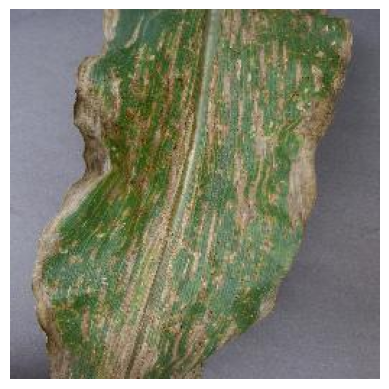

In [ ]:
#to plot the img, check shape
image_path='/content/plantvillage dataset/color/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot/00a20f6f-e8bd-4453-9e25-36ea70feb626___RS_GLSp 4655.JPG'

img= mpimg.imread(image_path)

print(img.shape)

plt.imshow(img)
plt.axis('off') #to disable axis numbers
plt.show()

#print some other images to confirm img size and channels

In [ ]:
#image parameters

img_size=224  #resizing to 224 as its commonly used
batch_size=32

In [ ]:
#image data generators
data_gen=ImageDataGenerator(
    rescale=1./255,       # rescale pixel values ranging upto 255 to between 0 and 1
    validation_split=0.2  # using 20% for validation
)

In [ ]:
#Train_generator
train_generator=data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size,img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

Found 43456 images belonging to 38 classes.


In [ ]:
# Validation_generator
validation_generator=data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size,img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

Found 10849 images belonging to 38 classes.


In [ ]:
## Convolutional Neural Networks

model=models.Sequential()

#convlution layers
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_size,img_size,3)))
model.add(layers.MaxPooling2D((2,2)))  #reducing the size of the image

#another convolutional layer to identify more complex features
model.add(layers.Conv2D(64,(3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# may use dropout layers to prevent overfitting

model.add(layers.Flatten())     #flattening layer flattens data to 1d vector to send to dense layers
model.add(layers.Dense(256,activation='relu'))
model.add(layers.Dense(train_generator.num_classes,activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 186624)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      47,776,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │           9,766 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 47,805,158 (182.36 MB)

 Trainable params: 47,805,158 (182.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# MODEL TRAINING

history=model.fit(
    train_generator,  #pass training data
    steps_per_epoch = train_generator.samples // batch_size,    #no of steps per epoch
    epochs=5,           #no of epochs
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 139s 96ms/step - accuracy: 0.6060 - loss: 1.8606 - val_accuracy: 0.8315 - val_loss: 0.5382
Epoch 2/5


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.9438
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 105s 74ms/step - accuracy: 0.9195 - loss: 0.2504 - val_accuracy: 0.8584 - val_loss: 0.4733
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 11us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 1.1921e-06
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 95s 69ms/step - accuracy: 0.9659 - loss: 0.1066 - val_accuracy: 0.8606 - val_loss: 0.5496


In [ ]:
# MODEL EVALUATION
print("Evaluating the model")
val_loss, val_accuracy=model.evaluate(validation_generator, steps =validation_generator.samples // batch_size)
print(f"validation accuracy: {val_accuracy *100:.2f}%")

Evaluating the model
339/339 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.8601 - loss: 0.5708
validation accuracy: 86.05%


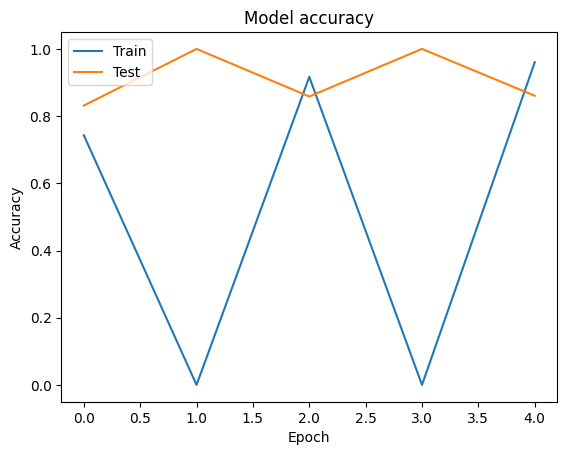

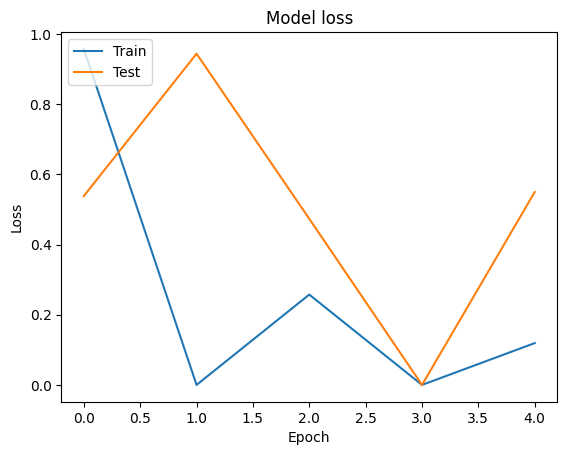

In [ ]:
# plotting training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

In [ ]:

def load_and_preprocess_image(image_path, target_size=(224,224)):
  img = Image.open(image_path)
  img=img.resize(target_size) #resize to target size
  img_array=np.array(img)
  img_array=np.expand_dims(img_array,axis=0)
  img_array=img_array.astype('float32') /255
  return img_array

# function to predict the class of an image provided
def predict_image_class(model, image_path, class_indices):
  preprocessed_img=load_and_preprocess_image(image_path)  # call load and preprocess function
  predictions=model.predict(preprocessed_img)  # predict using the model
  predicted_class_index=np.argmax(predictions,axis=1)[0]  #returns the index of highest probability value
  predicted_class_name=class_indices[predicted_class_index]  # get the class name  of predicted class index
  return predicted_class_name

In [ ]:
class_indices={v: k for k, v in train_generator.class_indices.items()}
class_indices


{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [ ]:
# saving the class names in a json file to use as a reference for the web application
json.dump(class_indices, open('class_indices.json', 'w'))

In [ ]:
# testing with random images
#example usage

image_path='/content/peach_bacterial.JPG'
# image_path='/content/corn health.jpg'
predicted_class_name=predict_image_class(model, image_path, class_indices)
print(f"Predicted class: {predicted_class_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
Predicted class: Peach___Bacterial_spot


In [ ]:
model.save('drive/MyDrive/Projects/plant_disease_prediction_model_color.h5')